In [105]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [106]:
def f(x):
  return 3*x**2 - 4*x+5

In [107]:
f(3.0)

20.0

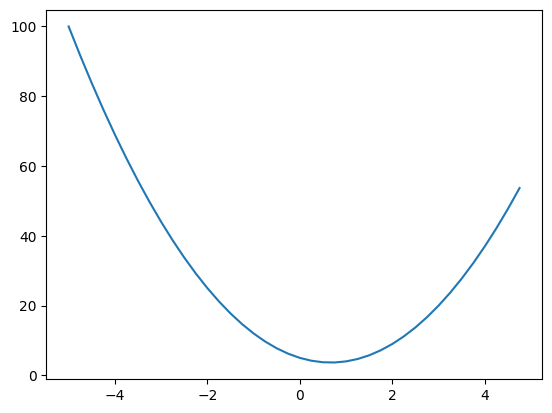

In [108]:
xs=np.arange(-5,5,0.25)
xs
ys=f(xs)
ys

plt.plot(xs,ys)

In [109]:
h=0.000001
x=2/3

(f(x+h) -f(x))/h

2.999378523327323e-06

In [110]:
a=2.0
b=-3.0
c=10.0

d=a*b+c

print(d)

4.0


In [111]:
h=0.0001

d1=a*b+c
c+=h
d2=a*b+c

print('d1',d1)
print('d2',d2)

print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [112]:
class Value:

  def __init__(self,data, _children=(), _op='', label=''):
    self.data=data
    self._prev=set(_children)
    self._op=_op
    self._backward=lambda: None
    self.label=label
    self.grad=0.0

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    other=other if isinstance(other, Value) else Value(other)
    out=Value(self.data+other.data, (self,other), '+')
    def _backward():
      self.grad+=1.0*out.grad
      other.grad+=1.0*out.grad

    out._backward=_backward
    return out

  def __radd__(self,other):
    return self+other

  def __mul__(self,other):
    other=other if isinstance(other, Value) else Value(other)
    out=Value(self.data*other.data, (self,other),'*')
    def _backward():
      self.grad+=other.data*out.grad
      other.grad+=self.data*out.grad
    out._backward=_backward
    return out

  def __rmul__(self,other):
    return self*other

  def __truediv__(self,other):
    return self*other**-1

  def __pow__(self,other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out=Value(self.data**other, (self,), '**')
    def _backward():
      self.grad+=other*(self.data**(other-1))*out.grad
    out._backward=_backward
    return out

  def __sub__(self,other):
    return self+(-other)

  def __neg__(self):
    return self*-1


  def tanh(self):
    x=self.data
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out=Value(t, (self,), 'tanh')
    def _backward():
      self.grad+=(1-t**2)*out.grad
    out._backward=_backward
    return out

  def exp(self):
    x=self.data
    out=Value(math.exp(x), (self,), 'exp')
    def _backward():
      self.grad+=out.data*out.grad
    out._backward=_backward
    return out

  def backward(self):
    topo=[]
    visited=set()
    def build_topo(root):
      if root not in visited:
        visited.add(root)
        for child in root._prev:
          build_topo(child)
        topo.append(root)
    build_topo(self)

    self.grad=1.0
    for node in reversed(topo):
      node._backward()

In [113]:

a=Value(2.0, label='a')
b=Value(3.0, label='b')
c=Value(10.0, label='c')
a/b

Value(data=0.6666666666666666)

In [114]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record'
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [115]:
# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b  = Value(6.8813735870195432, label='b')

# Step 1: Multiply x1 and w1
x1w1 = x1 * w1
x1w1.label = 'x1w1'

# Step 2: Multiply x2 and w2
x2w2 = x2 * w2
x2w2.label = 'x2w2'

# Step 3: Add the two products
x1w1_x2w2 = x1w1 + x2w2
x1w1_x2w2.label = 'x1w1_x2w2'

# Step 4: Add bias
y = x1w1_x2w2 + b
y.label = 'y'

o=y.tanh()
o.label='o'


# Forward pass result
o.backward()
      # Should print Value(data=0.8813735870195432, ...)

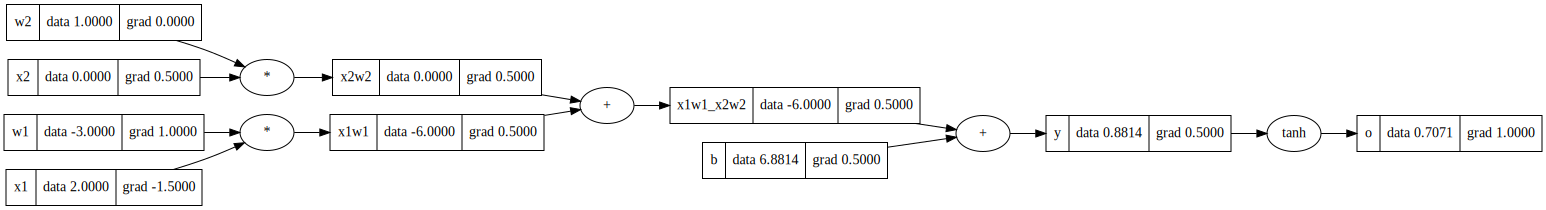

In [116]:
draw_dot(o)

In [117]:
# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b  = Value(6.8813735870195432, label='b')

# Step 1: Multiply x1 and w1
x1w1 = x1 * w1
x1w1.label = 'x1w1'

# Step 2: Multiply x2 and w2
x2w2 = x2 * w2
x2w2.label = 'x2w2'

# Step 3: Add the two products
x1w1_x2w2 = x1w1 + x2w2
x1w1_x2w2.label = 'x1w1_x2w2'

# Step 4: Add bias
e = x1w1_x2w2 + b
y.label = 'y'

e=(2*y).exp()
e.label='e'
o=(e-1)/(e+1)
o.label='o'


# Forward pass result
o.backward()
      # Should print Value(data=0.8813735870195432, ...)

In [118]:


class Neuron:
  def __init__(self, nin):
    self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b=Value(random.uniform(-1,1))

  def __call__(self, x):
    act=sum((wi*xi for wi, xi in zip(self.w, x)),self.b)
    out=act.tanh()
    return out

  def parameters(self):
    return self.w+[self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons=[Neuron(nin) for _ in range(nout)]
  def __call__(self, x):
    outs=[n(x) for n in self.neurons]
    return outs[0] if len(outs)==1 else outs
  def parameters(self):
    params=[]
    for neuron in self.neurons:
      params.extend(neuron.parameters())
    return params


class MLP:
  def __init__(self,nin,nouts):
    sz= [nin]+nouts
    self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x


  def parameters(self):
    params=[]
    for layer in self.layers:
      params.extend(layer.parameters())
    return params


In [119]:
x=[2.0,3.0,4.0]
n=MLP(2,[4,4,1])
n(x)

Value(data=-0.7669969688756707)

In [124]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]

ys=[1.0,-1.0,-1.0,1.0]



In [145]:
for i in range(100):
  ypred=[n(x) for x in xs]
  loss= sum([(yout -ygt)**2 for ygt,yout in zip(ys,ypred)])

  print(loss.data)

  for p in n.parameters():
    p.grad = 0.0

  loss.backward()

  for p in n.parameters():
    p.data+=-0.01*p.grad



0.02756871964859192
0.02747030862366831
0.02737252042097237
0.027275349481228672
0.027178790308642644
0.027082837470023095
0.02698748559391804
0.026892729369765583
0.026798563547057033
0.026704982934514836
0.02661198239928287
0.026519556866129737
0.02642770131666515
0.026336410788568645
0.02624568037482983
0.026155505223002123
0.02606588053446663
0.02597680156370903
0.02588826361760691
0.025800262054728636
0.025712792284643335
0.025625849767241478
0.025539430012065788
0.025453528577653116
0.025368141070886217
0.025283263146355622
0.025198890505731104
0.0251150188971434
0.025031644114575057
0.024948761997260448
0.02486636842909535
0.024784459338055648
0.024703030695624177
0.024622078516227365
0.02454159885667919
0.024461587815634653
0.024382041533051013
0.02430295618965679
0.024224328006429742
0.024146153244081682
0.024068428202551565
0.02399114922050595
0.023914312674847067
0.023837914980227977
0.023761952588575233
0.023686421988618263
0.023611319705426223
0.02353664229995075
0.0234623

In [126]:
#loss.backward()
n.parameters()

[Value(data=-0.2247180715041347),
 Value(data=-0.1539624096890089),
 Value(data=-1.1214040465023494),
 Value(data=-0.9855275652932725),
 Value(data=0.3351361135100215),
 Value(data=0.0743789971916598),
 Value(data=0.40310489509392644),
 Value(data=1.125412014812622),
 Value(data=-1.0052939887451022),
 Value(data=-0.8473517922322442),
 Value(data=0.13754186253460238),
 Value(data=0.15301731135183125),
 Value(data=0.2403237142352208),
 Value(data=-0.25354331784982453),
 Value(data=0.7858947369308592),
 Value(data=-0.6396906668209569),
 Value(data=-0.4328360294073618),
 Value(data=0.6855787190897222),
 Value(data=0.7927772991154505),
 Value(data=-0.5299971177337996),
 Value(data=-0.2574415773123039),
 Value(data=-0.5649599255771902),
 Value(data=0.6264410805729351),
 Value(data=0.5514232464265503),
 Value(data=0.008903326455789675),
 Value(data=0.824246461646404),
 Value(data=0.24210854392621117),
 Value(data=0.6059177743194755),
 Value(data=-0.2814989039324422),
 Value(data=1.20194196796

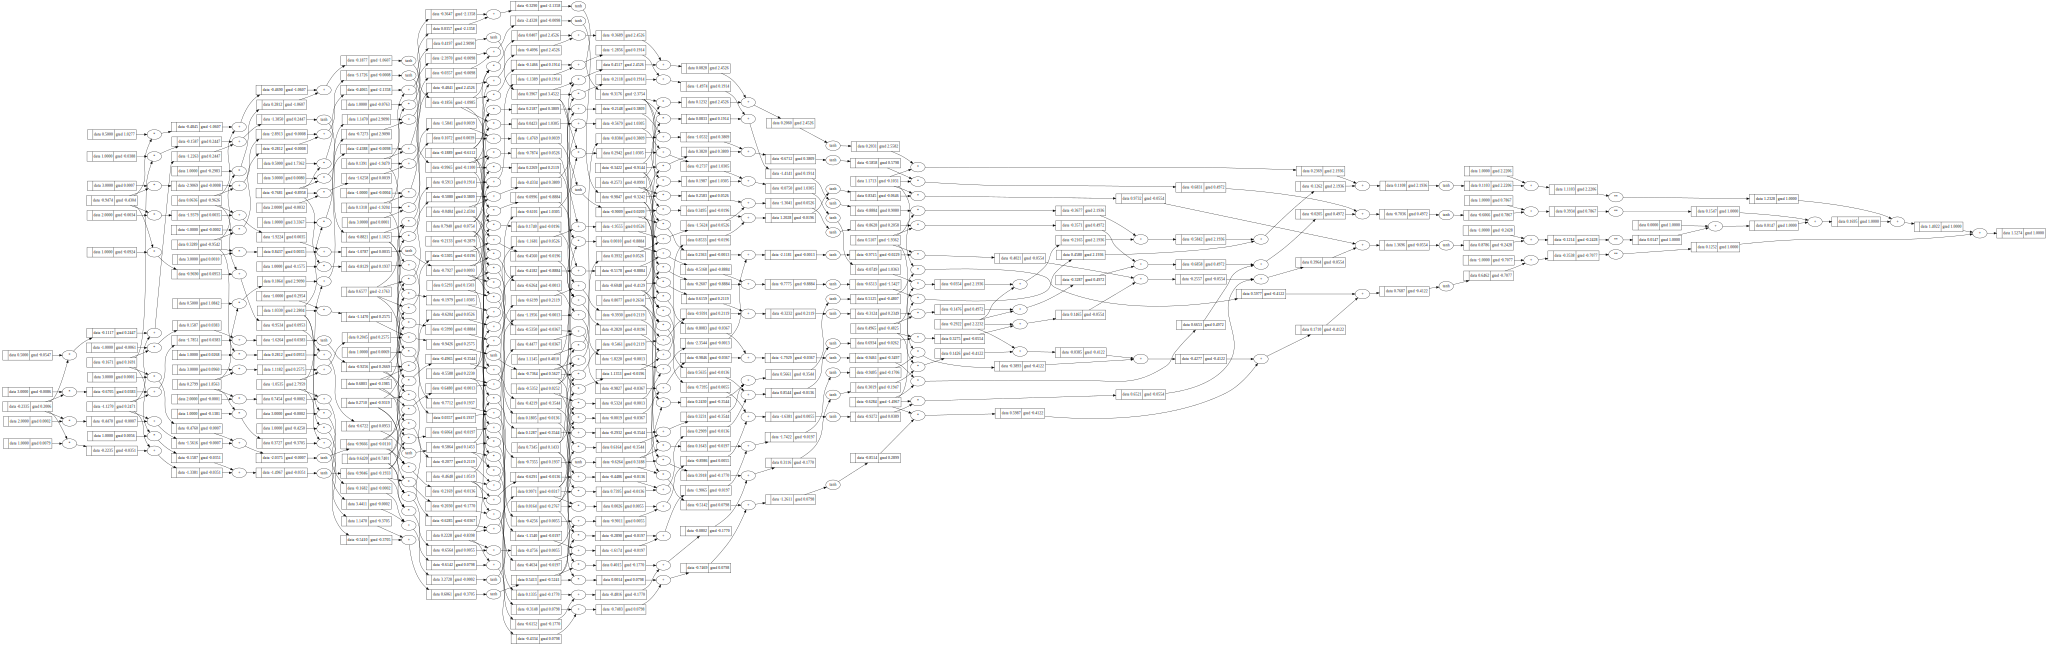

In [123]:
draw_dot(loss)